In [2]:
# ── Imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [ ]:
# ── Settings ─────────────────────────────────────────────────────────────
IMG_SIZE          = 224
BATCH_SIZE        = 32
NUM_EPOCHS        = 10
SAMPLES_PER_CLASS = 200  # limit for CPU training

DATA_DIR = r"path/to/PlantVillage-Dataset/raw/color"

print(f"Image size:         {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Epochs:             {NUM_EPOCHS}")
print(f"Samples per class:  {SAMPLES_PER_CLASS}")
print(f"Data dir exists:    {os.path.exists(DATA_DIR)}")
print(f"Number of classes:  {len(os.listdir(DATA_DIR))}")

Image size:         224x224
Batch size:         32
Epochs:             10
Samples per class:  200
Data dir exists:    True
Number of classes:  38


In [5]:
# ── Load Data with correct preprocessing ──────────────────────────────────
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

print(f"Loading {SAMPLES_PER_CLASS} images per class...")

X, y = [], []
class_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)
    images = os.listdir(class_path)[:SAMPLES_PER_CLASS]
    loaded = 0
    for img_file in images:
        try:
            img = Image.open(os.path.join(class_path, img_file)).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(img, dtype=np.float32)
            img_array = eff_preprocess(img_array)  # correct preprocessing!
            X.append(img_array)
            y.append(idx)
            loaded += 1
        except:
            continue
    print(f"  {idx+1}/{len(class_names)} {class_name}: {loaded} images")

X = np.array(X, dtype=np.float32)
y = to_categorical(np.array(y))

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NUM_CLASSES = len(class_names)
print(f"\nTotal images:       {len(X)}")
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Number of classes:  {NUM_CLASSES}")

Loading 200 images per class...
  1/38 Apple___Apple_scab: 200 images
  2/38 Apple___Black_rot: 200 images
  3/38 Apple___Cedar_apple_rust: 200 images
  4/38 Apple___healthy: 200 images
  5/38 Blueberry___healthy: 200 images
  6/38 Cherry_(including_sour)___Powdery_mildew: 200 images
  7/38 Cherry_(including_sour)___healthy: 200 images
  8/38 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 200 images
  9/38 Corn_(maize)___Common_rust_: 200 images
  10/38 Corn_(maize)___Northern_Leaf_Blight: 200 images
  11/38 Corn_(maize)___healthy: 200 images
  12/38 Grape___Black_rot: 200 images
  13/38 Grape___Esca_(Black_Measles): 200 images
  14/38 Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 200 images
  15/38 Grape___healthy: 200 images
  16/38 Orange___Haunglongbing_(Citrus_greening): 200 images
  17/38 Peach___Bacterial_spot: 200 images
  18/38 Peach___healthy: 200 images
  19/38 Pepper,_bell___Bacterial_spot: 200 images
  20/38 Pepper,_bell___healthy: 200 images
  21/38 Potato___Early_blig

Total classes: 38
Total images in dataset: 54305


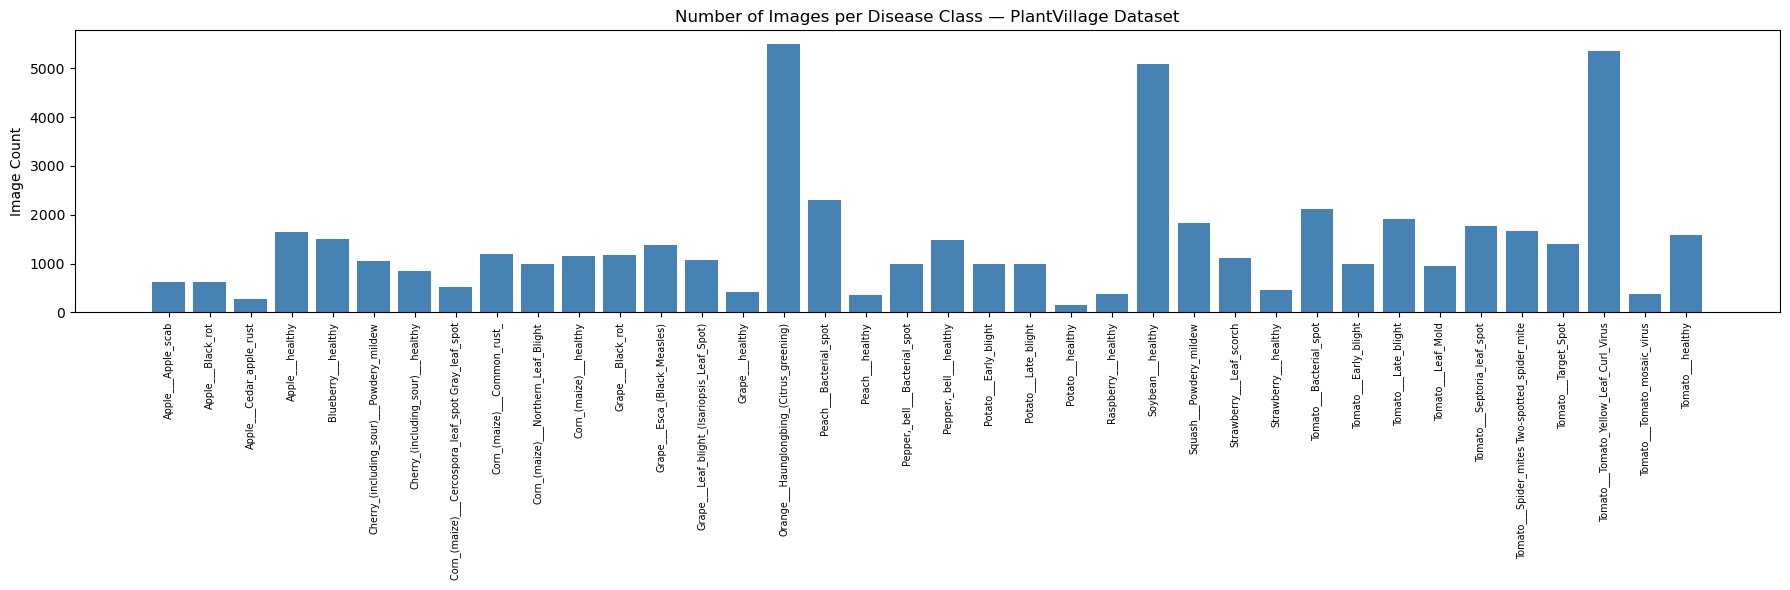

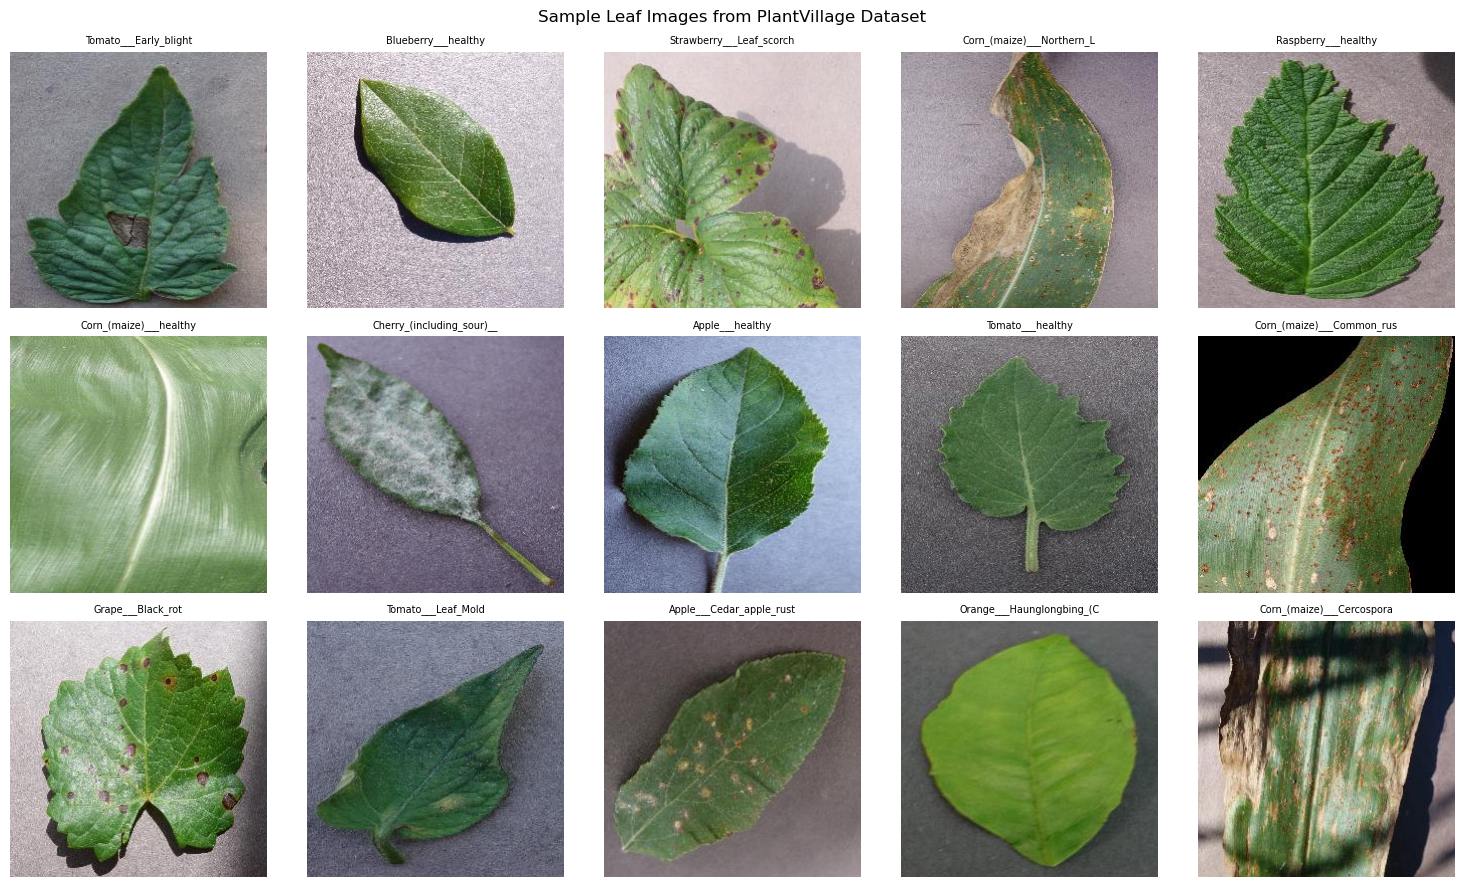

In [6]:
# ── EDA ──────────────────────────────────────────────────────────────────
class_counts = {}
for idx, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

print(f"Total classes: {len(class_names)}")
print(f"Total images in dataset: {sum(class_counts.values())}")

# Bar chart
plt.figure(figsize=(18, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.xticks(rotation=90, fontsize=7)
plt.title('Number of Images per Disease Class — PlantVillage Dataset')
plt.ylabel('Image Count')
plt.tight_layout()
plt.show()

# Sample images
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_classes = random.sample(class_names, 15)
for ax, cls in zip(axes.flat, sample_classes):
    img_file = random.choice(os.listdir(os.path.join(DATA_DIR, cls)))
    img = Image.open(os.path.join(DATA_DIR, cls, img_file))
    ax.imshow(img)
    ax.set_title(cls[:25], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Leaf Images from PlantVillage Dataset')
plt.tight_layout()
plt.show()

In [1]:
import gc
import tensorflow as tf

# Clear any existing variables
try:
    del X, y, X_train, X_val, y_train, y_val
except:
    pass

# Clear TensorFlow session
tf.keras.backend.clear_session()

# Force garbage collection
gc.collect()

print("RAM cleared ✅")


RAM cleared ✅


In [7]:
# ── EfficientNetB3 Model ──────────────────────────────────────────────────
def build_efficientnet(num_classes):
    base_model = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model, base_model

print("EfficientNetB3 architecture defined ✅")

EfficientNetB3 architecture defined ✅


In [8]:
# ── Helper Functions ──────────────────────────────────────────────────────
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X, y, class_names, title):
    y_pred = model.predict(X, verbose=1)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y, axis=1)

    accuracy = np.mean(y_pred_classes == y_true)
    print(f"\n{title} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_classes,
                                target_names=class_names))

    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(20, 18))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'{title} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return accuracy

print("Helper functions defined ✅")

Helper functions defined ✅


In [9]:
# ── Train EfficientNetB3 ──────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

# Phase 1 — frozen base
print("=" * 60)
print("PHASE 1 — Training top layers (frozen base)")
print("=" * 60)

model_eff, base_model = build_efficientnet(NUM_CLASSES)
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_eff.summary()

history_phase1 = model_eff.fit(
    X_train, y_train,
    epochs=NUM_EPOCHS,
    batch_size=16,           # reduced from 32
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

# Phase 2 — fine-tuning
print("\n" + "=" * 60)
print("PHASE 2 — Fine-tuning (unfreezing last 10 layers only)")
print("=" * 60)

base_model.trainable = True
for layer in base_model.layers[:-10]:  # only last 10 layers (was 30)
    layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model_eff.fit(
    X_train, y_train,
    epochs=NUM_EPOCHS,
    batch_size=16,           # reduced from 32
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

os.makedirs('./models', exist_ok=True)
model_eff.save('./models/efficientnetb3_case2.keras')
print("EfficientNetB3 Case 2 saved ✅")

PHASE 1 — Training top layers (frozen base)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,186,773 (42.67 MB)

 Trainable params: 403,238 (1.54 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

Epoch 1/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 346s 884ms/step - accuracy: 0.2659 - loss: 2.9222 - val_accuracy: 0.6664 - val_loss: 1.9049 - learning_rate: 1.0000e-04
Epoch 2/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 331s 877ms/step - accuracy: 0.5762 - loss: 1.7008 - val_accuracy: 0.7856 - val_loss: 1.0981 - learning_rate: 1.0000e-04
Epoch 3/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 334s 884ms/step - accuracy: 0.6868 - loss: 1.2049 - val_accuracy: 0.8372 - val_loss: 0.7932 - learning_rate: 1.0000e-04
Epoch 4/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 306s 810ms/step - accuracy: 0.7418 - loss: 0.9581 - val_accuracy: 0.8557 - val_loss: 0.6331 - learning_rate: 1.0000e-04
Epoch 5/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 298s 788ms/step - accuracy: 0.7812 - loss: 0.8035 - val_accuracy: 0.8776 - val_loss: 0.5384 - learning_rate: 1.0000e-04
Epoch 6/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 283s 748ms/step - accuracy: 0.8063 - loss: 0.6996 - val_accuracy: 0.8782 - val_loss: 0.4775 - learning_rate: 1.0000e-04
Epoch 7/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 

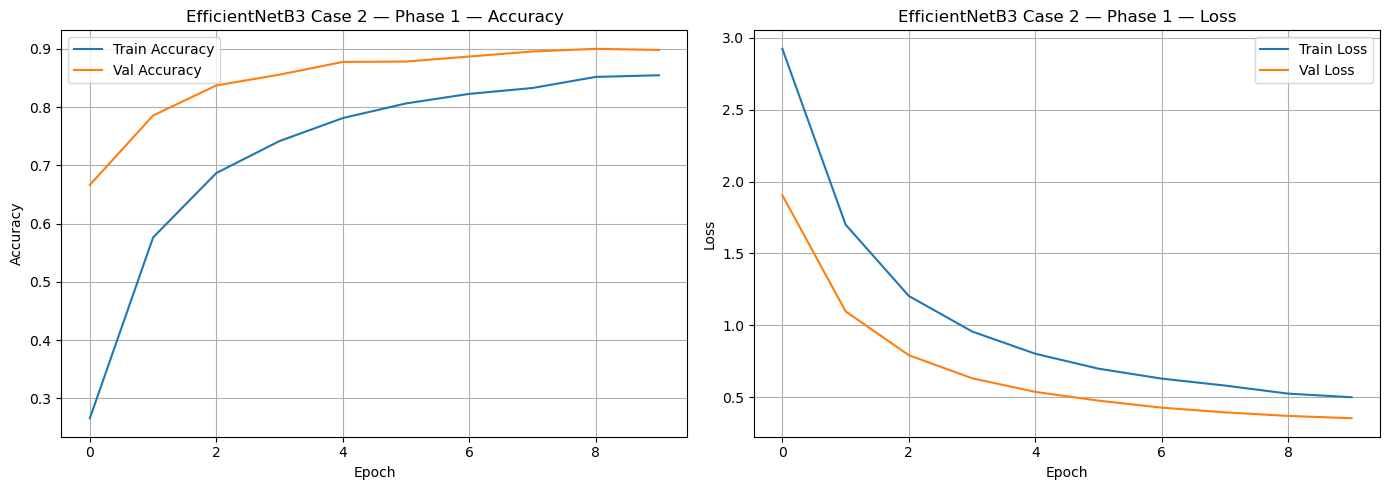

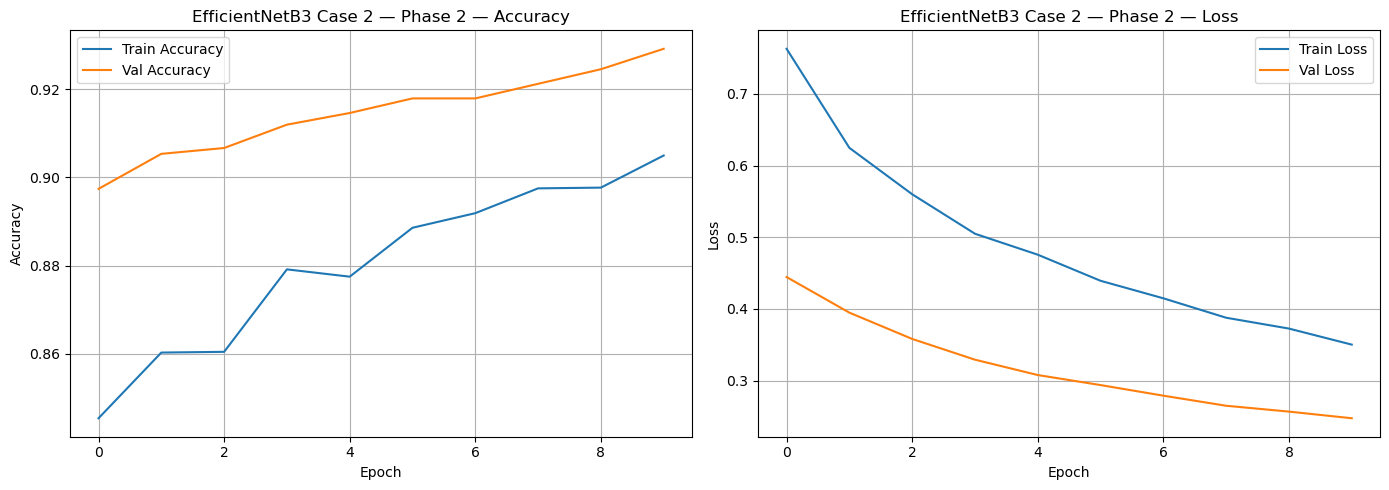

48/48 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step

EfficientNetB3 Case 2 Accuracy: 0.9292 (92.92%)

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.98      0.97        46
                                 Apple___Black_rot       1.00      1.00      1.00        42
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        48
                                   Apple___healthy       1.00      0.97      0.99        37
                               Blueberry___healthy       1.00      0.97      0.98        31
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98        52
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00        34
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.76      0.83        54
                       Corn_(maize)___Common_rust_       0.

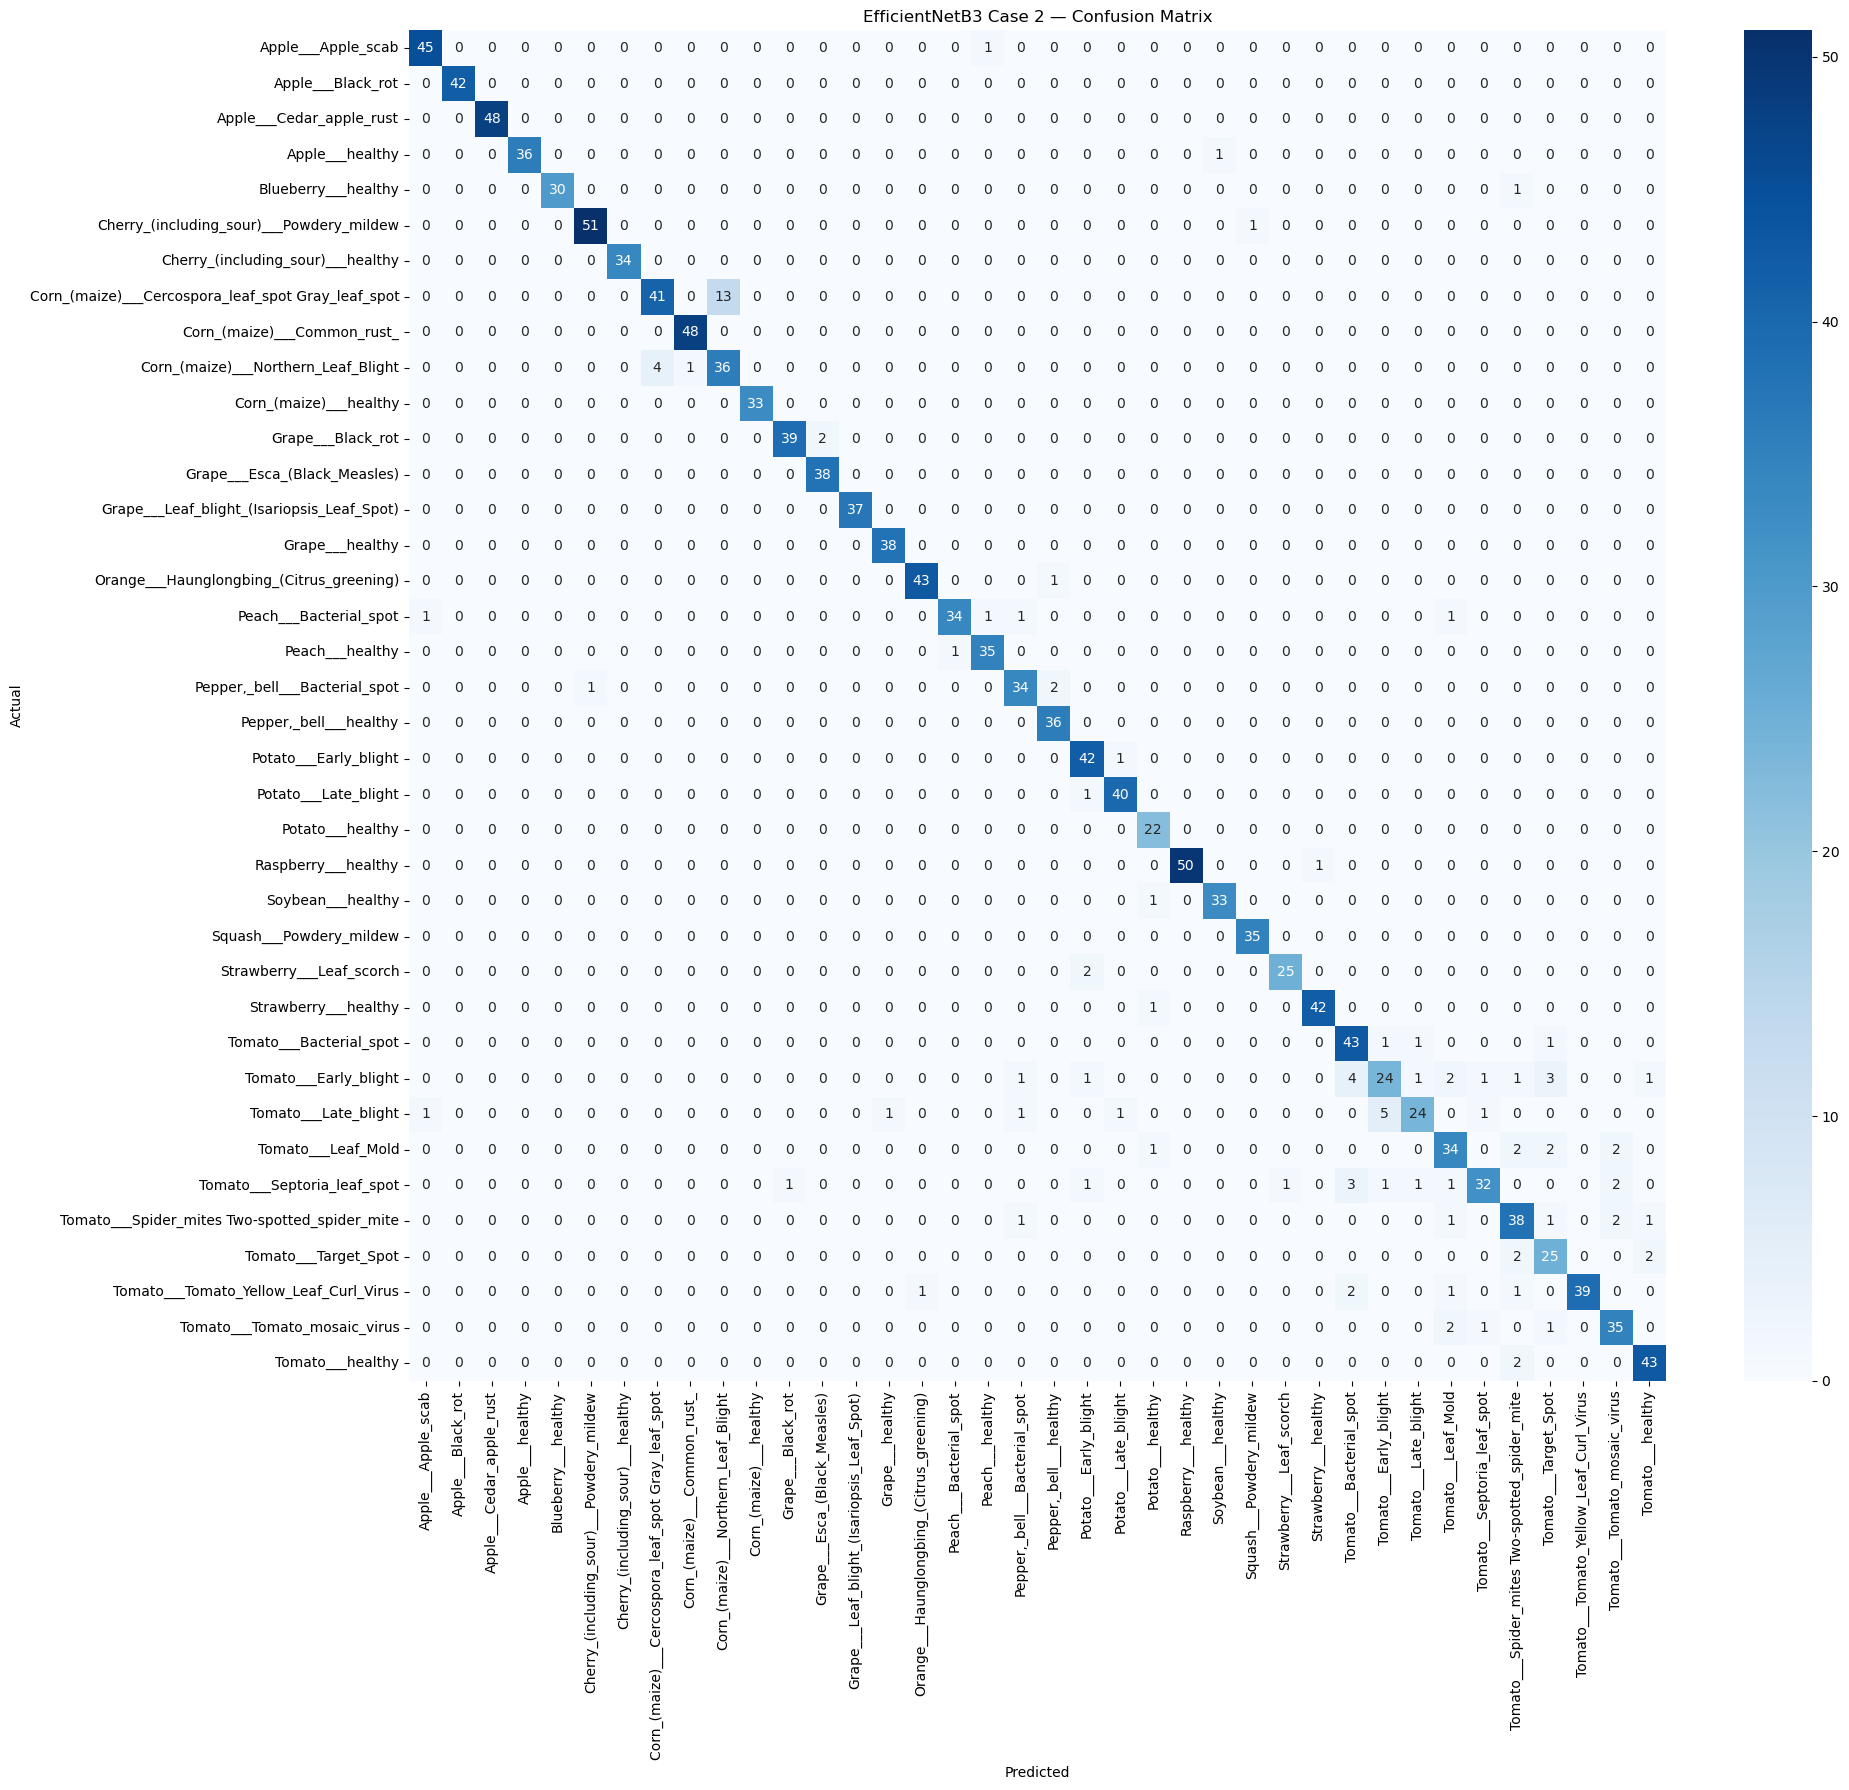


Final Accuracy: 92.92%


In [10]:
# ── Evaluate EfficientNetB3 ───────────────────────────────────────────────
plot_history(history_phase1, "EfficientNetB3 Case 2 — Phase 1")
plot_history(history_phase2, "EfficientNetB3 Case 2 — Phase 2")

eff_accuracy = evaluate_model(
    model_eff, X_val, y_val, class_names, "EfficientNetB3 Case 2"
)
print(f"\nFinal Accuracy: {eff_accuracy*100:.2f}%")

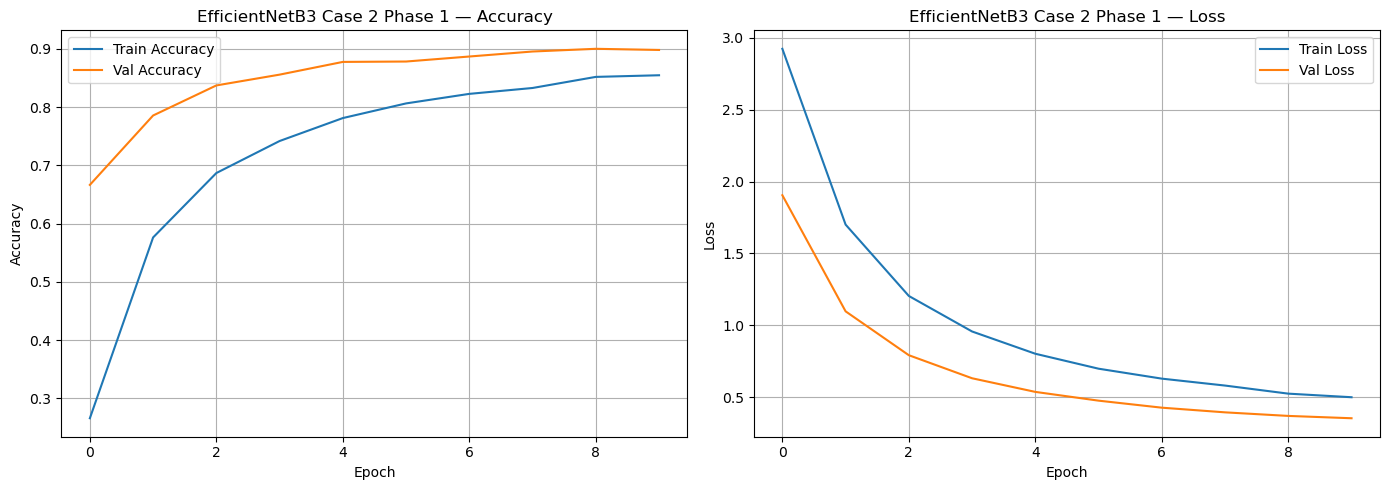

Phase 1 history saved ✅


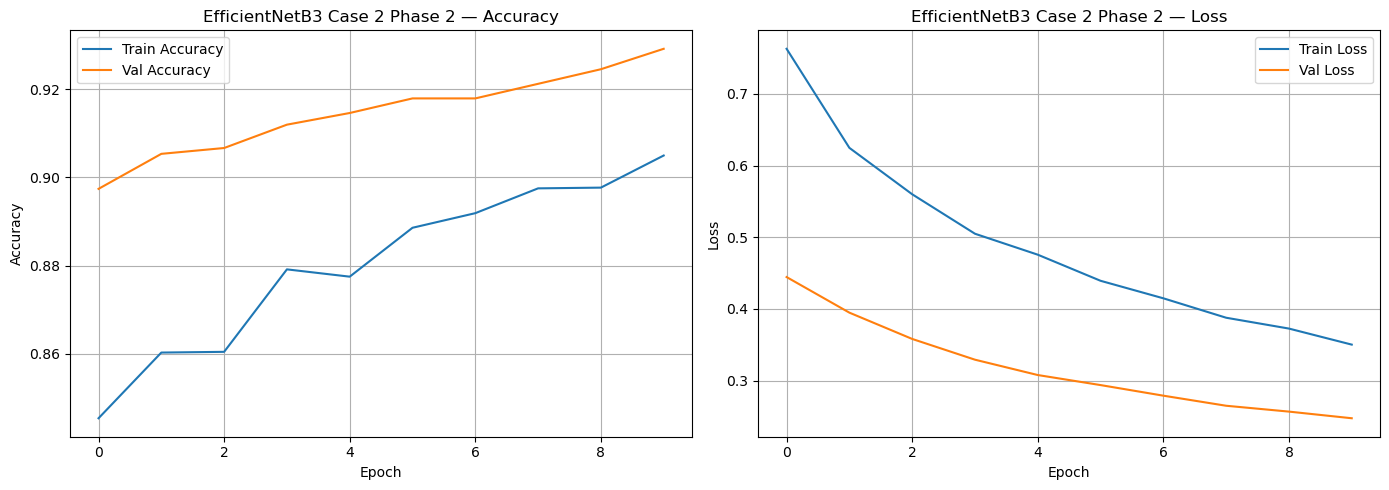

Phase 2 history saved ✅
48/48 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step


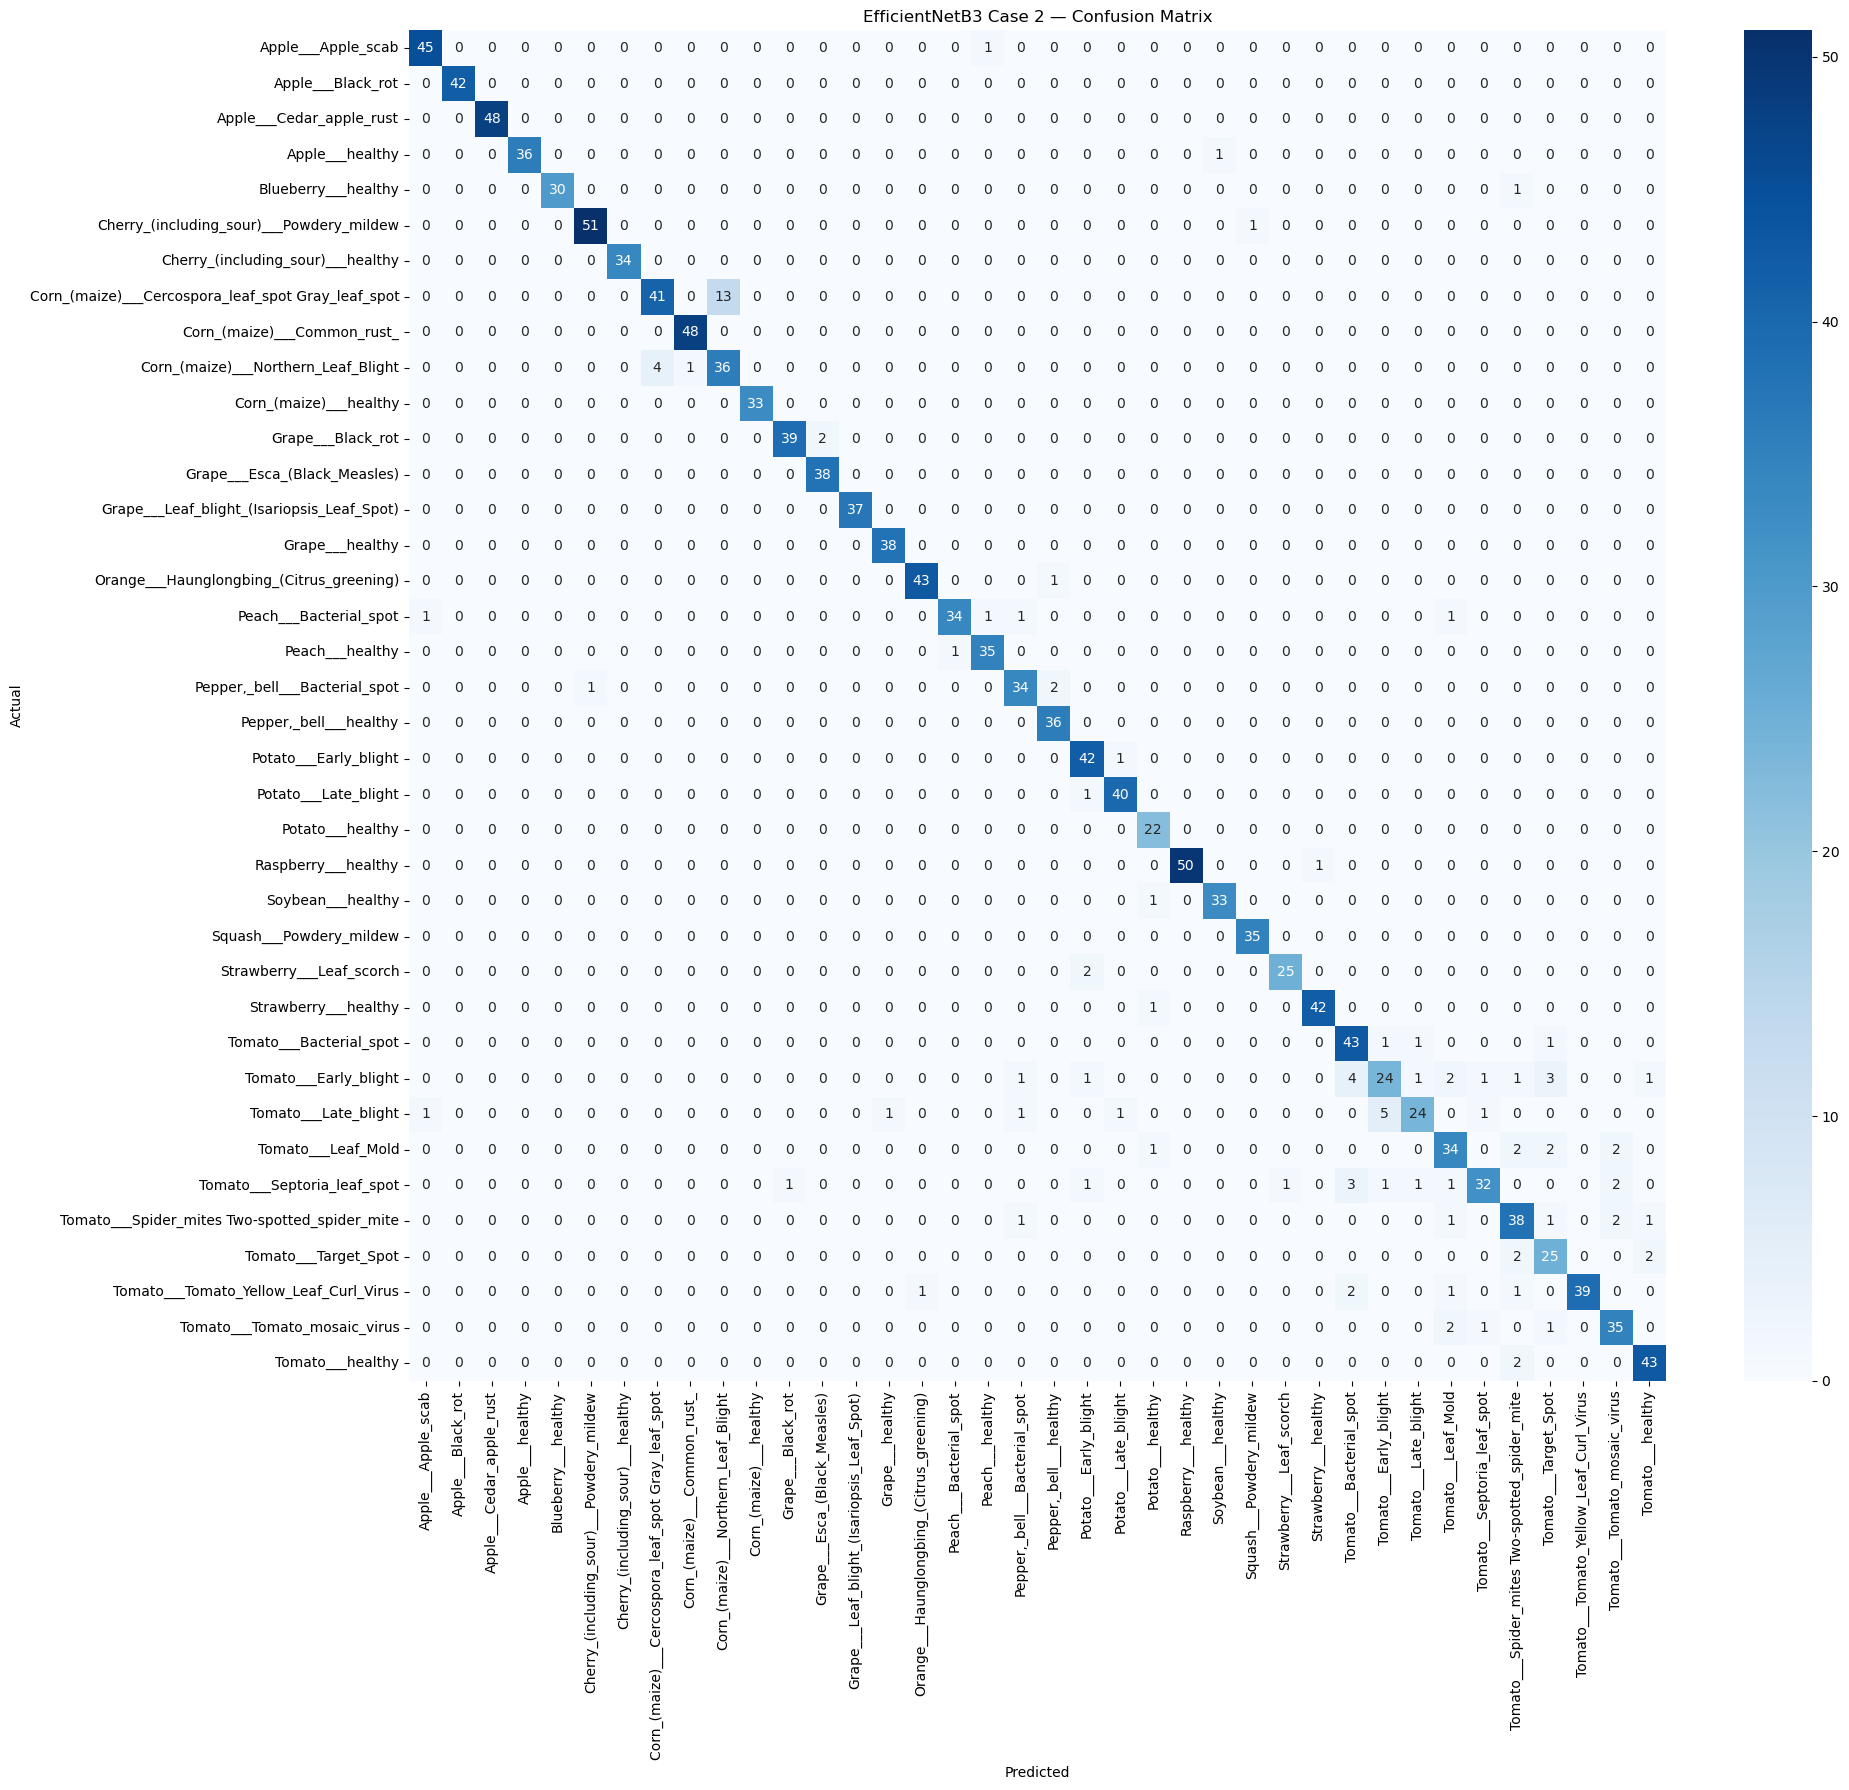

Confusion matrix saved ✅
Classification report saved ✅
Accuracy summary saved ✅

All outputs saved to ./results/ folder ✅
Final Accuracy: 92.92%


In [11]:
# ── Save All Outputs ──────────────────────────────────────────────────────
import os

os.makedirs('./results', exist_ok=True)

# Save Phase 1 history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_phase1.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_phase1.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('EfficientNetB3 Case 2 Phase 1 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history_phase1.history['loss'], label='Train Loss')
axes[1].plot(history_phase1.history['val_loss'], label='Val Loss')
axes[1].set_title('EfficientNetB3 Case 2 Phase 1 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('./results/phase1_history.png', dpi=150)
plt.show()
print("Phase 1 history saved ✅")

# Save Phase 2 history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_phase2.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_phase2.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('EfficientNetB3 Case 2 Phase 2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history_phase2.history['loss'], label='Train Loss')
axes[1].plot(history_phase2.history['val_loss'], label='Val Loss')
axes[1].set_title('EfficientNetB3 Case 2 Phase 2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('./results/phase2_history.png', dpi=150)
plt.show()
print("Phase 2 history saved ✅")

# Save confusion matrix
y_pred = model_eff.predict(X_val, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('EfficientNetB3 Case 2 — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('./results/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved ✅")

# Save classification report
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred_classes,
                               target_names=class_names)
with open('./results/classification_report.txt', 'w') as f:
    f.write(report)
print("Classification report saved ✅")

# Save accuracy summary
with open('./results/accuracy_summary.txt', 'w') as f:
    f.write(f"EfficientNetB3 Case 2 Results\n")
    f.write(f"=" * 40 + "\n")
    f.write(f"Dataset: PlantVillage (original)\n")
    f.write(f"Images per class: {SAMPLES_PER_CLASS}\n")
    f.write(f"Total training images: {len(X_train)}\n")
    f.write(f"Total validation images: {len(X_val)}\n")
    f.write(f"Number of classes: {NUM_CLASSES}\n")
    f.write(f"Final Accuracy: {eff_accuracy*100:.2f}%\n")
print("Accuracy summary saved ✅")

print(f"\nAll outputs saved to ./results/ folder ✅")
print(f"Final Accuracy: {eff_accuracy*100:.2f}%")